Generating and downloading 4 complex datasets...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: xor_crosshair.csv


<IPython.core.display.Javascript object>

...

Downloaded: extreme_moons.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully generated and downloaded bullseye_spatial_data.csv!
Upload a CSV file containing your 2D spatial data.
(Format: Column 1 = X, Column 2 = Y, Column 3 = Label [0 or 1])


Saving bullseye_spatial_data.csv to bullseye_spatial_data (1).csv
User uploaded file "bullseye_spatial_data (1).csv"

--- Processing Custom Data ---
Training CortexNet on custom data...
Training Complete! Validation Accuracy: 93.50%



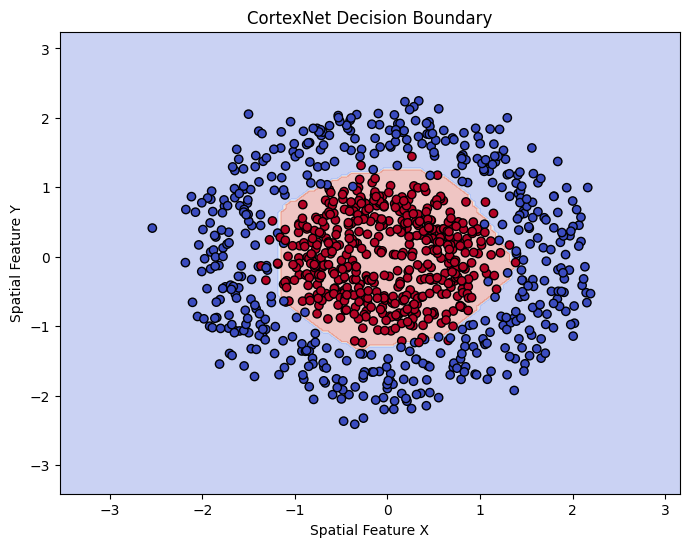

Upload a CSV file containing your 2D spatial data.


Output()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import files
import pandas as pd
from sklearn.datasets import make_circles
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
import pandas as pd
# 1. Generate a "bullseye" non-linear dataset
X_custom, y_custom = make_circles(n_samples=1000, noise=0.15, factor=0.4, random_state=42)

# 2. Package it into a DataFrame (X, Y, Label)
df_custom = pd.DataFrame({
    'Feature_X': X_custom[:, 0],
    'Feature_Y': X_custom[:, 1],
    'Label': y_custom
})

# 3. Save as a CSV file
csv_filename = "bullseye_spatial_data.csv"
df_custom.to_csv(csv_filename, index=False)
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from google.colab import files
import time

datasets = {}

# 1. The XOR Crosshair (Noise added)
X_xor = np.random.uniform(-3, 3, (1000, 2))
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0).astype(int)
X_xor += np.random.normal(0, 0.3, X_xor.shape)
datasets['xor_crosshair.csv'] = (X_xor, y_xor)

# 2. Interlocking Spirals (Complex Geometry)
n_samples = 1000
theta = np.sqrt(np.random.rand(n_samples // 2)) * 3 * np.pi
r_a = 2 * theta + np.pi
x_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T + np.random.randn(n_samples // 2, 2) * 0.5
r_b = -2 * theta - np.pi
x_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T + np.random.randn(n_samples // 2, 2) * 0.5
X_spirals = np.vstack((x_a, x_b))
y_spirals = np.hstack((np.zeros(n_samples // 2), np.ones(n_samples // 2)))
datasets['interlocking_spirals.csv'] = (X_spirals, y_spirals)

# 3. The Sine Wave Split (Continuous curve)
X_sin = np.random.uniform(-np.pi, np.pi, (1000, 2))
y_sin = (X_sin[:, 1] > np.sin(X_sin[:, 0])).astype(int)
X_sin += np.random.normal(0, 0.4, X_sin.shape)
datasets['sine_wave_split.csv'] = (X_sin, y_sin)

# 4. Extreme Moons (High Noise Overlap)
X_moons, y_moons = make_moons(n_samples=1000, noise=0.35, random_state=42)
datasets['extreme_moons.csv'] = (X_moons, y_moons)

# Save and Trigger Downloads
print("Generating and downloading 4 complex datasets...")
for filename, (X, y) in datasets.items():
    df = pd.DataFrame({'Feature_X': X[:, 0], 'Feature_Y': X[:, 1], 'Label': y})
    df.to_csv(filename, index=False)
    files.download(filename)
    print(f"Downloaded: {filename}")
    time.sleep(1) # Brief pause to ensure the browser processes all 4 downloads
# 4. Automatically download it to your local machine
files.download(csv_filename)
print(f"Successfully generated and downloaded {csv_filename}!")
# ==========================================
# 1. The CortexNet Architecture
# ==========================================
# (Re-defining here so the function is self-contained)
class CortexNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, output_dim=1, dropout_rate=0.3):
        super(CortexNet, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)
        self.output_layer = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.dropout1(self.relu1(self.layer1(x)))
        out = self.dropout2(self.relu2(self.layer2(out)))
        return self.sigmoid(self.output_layer(out))

# ==========================================
# 2. Decision Boundary Visualization
# ==========================================
def plot_decision_boundary(model, X, y, title="CortexNet Decision Boundary"):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.05 # Grid step size

    # Generate a grid of points
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the grid
    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    model.eval()
    with torch.no_grad():
        Z = model(grid_tensor).numpy().round()
    Z = Z.reshape(xx.shape)

    # Plot the contour and training examples
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.xlabel('Spatial Feature X')
    plt.ylabel('Spatial Feature Y')
    plt.show()

# ==========================================
# 3. The Universal Training Pipeline
# ==========================================
def run_custom_cortexnet(dataframe):
    print("\n--- Processing Custom Data ---")
    # Assume first two columns are X/Y coordinates, last column is the Label (0 or 1)
    X_raw = dataframe.iloc[:, :2].values
    y_raw = dataframe.iloc[:, -1].values

    # Auto-Scale the data so the neural network doesn't crash on large numbers
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # Split and Convert to Tensors
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_raw, test_size=0.2, random_state=42)

    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).view(-1, 1)
    X_test_t = torch.FloatTensor(X_test)
    y_test_t = torch.FloatTensor(y_test).view(-1, 1)

    # Initialize Model & Optimizer
    model = CortexNet()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

    # Train
    print("Training CortexNet on custom data...")
    epochs = 400
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

    # Validate
    model.eval()
    with torch.no_grad():
        accuracy = (model(X_test_t).round() == y_test_t).float().mean().item()
    print(f"Training Complete! Validation Accuracy: {accuracy*100:.2f}%\n")

    # Visualize the non-linear power
    plot_decision_boundary(model, X_scaled, y_raw)

# ==========================================
# 4. Interactive File Uploader
# ==========================================
print("Upload a CSV file containing your 2D spatial data.")
print("(Format: Column 1 = X, Column 2 = Y, Column 3 = Label [0 or 1])")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}"')
    # Read the uploaded CSV into a Pandas DataFrame
    df = pd.read_csv(io.BytesIO(uploaded[filename]))

    # Run the universal pipeline!
    run_custom_cortexnet(df)
# ==========================================
# 4. Interactive File Uploader (Upgraded UI)
# ==========================================
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
import pandas as pd

# 1. Create the UI Buttons
upload_widget = widgets.FileUpload(accept='.csv', multiple=False, description='Choose CSV')
cancel_button = widgets.Button(description='Cancel / Clear', button_style='danger', icon='trash')
output_display = widgets.Output()

# 2. Define what happens when a file is uploaded
def handle_upload(change):
    with output_display:
        clear_output() # Instantly clears the previous graph
        if upload_widget.value:
            # Extract file data (handles Colab's widget format)
            filename = list(upload_widget.value.keys())[0]
            file_content = upload_widget.value[filename]['content']

            print(f'\n--- Processing: "{filename}" ---')
            df = pd.read_csv(io.BytesIO(file_content))
            run_custom_cortexnet(df)

# 3. Define what happens when Cancel is clicked
def handle_cancel(b):
    with output_display:
        clear_output()
        print("Output cancelled and cleared! Ready for a new CSV.")

# 4. Link the buttons to their functions
upload_widget.observe(handle_upload, names='value')
cancel_button.on_click(handle_cancel)

# 5. Display the buttons side-by-side
print("Upload a CSV file containing your 2D spatial data.")
display(widgets.HBox([upload_widget, cancel_button]))
display(output_display)

In [ ]:
import pandas as pd
from sklearn.datasets import make_circles
from google.colab import files

# 1. Generate a "bullseye" non-linear dataset
X_custom, y_custom = make_circles(n_samples=1000, noise=0.15, factor=0.4, random_state=42)

# 2. Package it into a DataFrame (X, Y, Label)
df_custom = pd.DataFrame({
    'Feature_X': X_custom[:, 0],
    'Feature_Y': X_custom[:, 1],
    'Label': y_custom
})

# 3. Save as a CSV file
csv_filename = "bullseye_spatial_data.csv"
df_custom.to_csv(csv_filename, index=False)

# 4. Automatically download it to your local machine
files.download(csv_filename)
print(f"Successfully generated and downloaded {csv_filename}!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully generated and downloaded bullseye_spatial_data.csv!


In [ ]:
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler
from google.colab import files

# 1. Select the dataset you want to train your deployed model on
# (You can swap this with 'interlocking_spirals.csv' or 'bullseye_spatial_data.csv')
target_dataset = 'sine_wave_split.csv'
df_export = pd.read_csv(target_dataset)

# 2. Prepare and scale the data
X_raw = df_export.iloc[:, :2].values
y_raw = df_export.iloc[:, -1].values
X_scaled = StandardScaler().fit_transform(X_raw)

X_tensor = torch.FloatTensor(X_scaled)
y_tensor = torch.FloatTensor(y_raw).view(-1, 1)

# 3. Initialize and train the final model
export_model = CortexNet()
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(export_model.parameters(), lr=0.01, weight_decay=1e-4)

print(f"Training final CortexNet on {target_dataset}...")
for epoch in range(400):
    export_model.train()
    optimizer.zero_grad()
    loss = criterion(export_model(X_tensor), y_tensor)
    loss.backward()
    optimizer.step()

# 4. Save the brain and trigger the download
pth_filename = 'cortexnet_pro_weights.pth'
torch.save(export_model.state_dict(), pth_filename)
files.download(pth_filename)

print(f"Success! {pth_filename} has been generated and is downloading.")

Training final CortexNet on sine_wave_split.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Success! cortexnet_pro_weights.pth has been generated and is downloading.
